##### Copyright 2021 The TensorFlow Authors.

In [1]:
import pandas as pd
import plotly.express as px
import os

from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio

import params as yamnet_params
import yamnet as yamnet_model

In [2]:
params = yamnet_params.Params()
yamnet = yamnet_model.yamnet_frames_model(params)
yamnet.load_weights('yamnet.h5')
yamnet_classes = yamnet_model.class_names('yamnet_class_map.csv')

In [3]:
# testing if everything is working:
yamnet.summary()

Model: "yamnet_frames"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None,)]            0           []                               
                                                                                                  
 tf.compat.v1.shape (TFOpLambda  (1,)                0           ['input_1[0][0]']                
 )                                                                                                
                                                                                                  
 tf.__operators__.getitem (Slic  ()                  0           ['tf.compat.v1.shape[0][0]']     
 ingOpLambda)                                                                                     
                                                                                      

In [4]:
# check my GPU device is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')

print('Found GPU at: {}'.format(device_name))

SystemError: GPU device not found

In [5]:
# testing audio file
audio_file = "-0x1a0a4fce078dd9e.wav"
print(audio_file)

-0x1a0a4fce078dd9e.wav


In [6]:
@tf.function
def load_wav_16k_mono(filename, start_time, end_time):
    """ Load a WAV file, convert it to a float tensor, resample to 16 kHz single-channel audio. """
    file_contents = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(
          file_contents,
          desired_channels=1)
    
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)  # cast sample_rate to int64
    
    start_sample = tf.cast(start_time * tf.cast(sample_rate, tf.float32), tf.int32)
    end_sample = tf.cast(end_time * tf.cast(sample_rate, tf.float32), tf.int32)
    wav = wav[start_sample:end_sample]
    
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    
    return wav

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


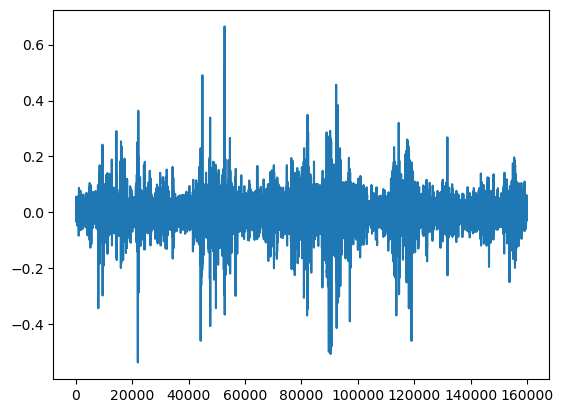

In [7]:
# run the model on the test file
audio_file = load_wav_16k_mono(audio_file, start_time=0, end_time=10)

_ = plt.plot(audio_file)

# Play the audio file.
display.Audio(audio_file, rate=16000)

In [8]:
# run the model, check the output.
scores, embeddings, spectrogram = yamnet(audio_file)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.argmax(class_scores)
inferred_class = yamnet_classes[top_class]

print(f'The main sound is: {inferred_class}')
print(f'The embeddings shape: {embeddings.shape}')

The main sound is: Boat, Water vehicle
The embeddings shape: (20, 1024)


### train

In [17]:
base_data_path = r"D:\AUDIOSET_STRONG"
base_train_path = r"train_16k"
train_csv = r"audioset_66_classes_folds.csv"

# pd_train = pd.read_csv(os.path.join(base_data_path, train_csv))
pd_train = pd.read_csv(train_csv)
pd_train.head()

,Unnamed: 0,segment_id,start_time_seconds,end_time_seconds,duration,clip_id,filename,mid,display_name,fold
0,0,b0RFKhbpFJA_30000,0.000,10.000,10.000,0x7b99cd732dabfef0,0x7b99cd732dabfef0.wav,/m/03m9d0z,Wind,1
1,1,ZvAdd4Jb1xA_30000,0.000,10.000,10.000,-0x6da6a8a6c54e3ad,-0x6da6a8a6c54e3ad.wav,/m/03m9d0z,Wind,1
2,2,sWdJR9dInhw_19000,0.000,9.803,9.803,-0x52b316ded52fb65e,-0x52b316ded52fb65e.wav,/m/03m9d0z,Wind,1
3,3,3zOfKHtXxws_30000,0.000,10.000,10.000,0x4ea20c5a7d1cf994,0x4ea20c5a7d1cf994.wav,/m/03m9d0z,Wind,1
4,4,0r4zxu38gt0_0,0.083,10.000,9.917,0x5a0670380b88cad7,0x5a0670380b88cad7.wav,/m/03m9d0z,Wind,1


In [10]:
# label the folds for evaluation.
# 1. get the unique labels
labels = pd_train['display_name'].unique()
# print(labels)
print("Total labels: ", len(labels))

# 2. create a dictionary with the labels
label_dict = {}
for index, label in enumerate(labels):
    label_dict[label] = index
    
print(label_dict)

# count the number of files per label
label_count = {}
for index, row in pd_train.iterrows():
    label = row['display_name']
    if label in label_count:
        label_count[label] += 1
    else:
        label_count[label] = 1
        
print(f"\nThis is the count for labels:\n {label_count}")

Total labels:  64
{'Wind': 0, 'Power tool': 1, 'Shout': 2, 'Mechanisms': 3, 'Bark': 4, 'Conversation': 5, 'Speech': 6, 'Dog': 7, 'Bird vocalization, bird call, bird song': 8, 'Bird': 9, 'Wind noise (microphone)': 10, 'Chirp, tweet': 11, 'Engine starting': 12, 'Hubbub, speech noise, speech babble': 13, 'Motor vehicle (road)': 14, 'Car': 15, 'Car alarm': 16, 'Medium engine (mid frequency)': 17, 'Water': 18, 'Rain': 19, 'Alarm': 20, 'Ocean': 21, 'Ship': 22, 'Light engine (high frequency)': 23, 'Tools': 24, 'Truck': 25, 'Thump, thud': 26, 'Traffic noise, roadway noise': 27, 'Screaming': 28, 'Motorcycle': 29, 'Squeak': 30, 'Reversing beeps': 31, 'Ambulance (siren)': 32, 'Clang': 33, 'Engine': 34, 'Waves, surf': 35, 'Whistle': 36, 'Siren': 37, 'Stream': 38, 'Mechanical fan': 39, 'Air horn, truck horn': 40, 'Rain on surface': 41, 'Engine knocking': 42, 'Car passing by': 43, 'Air brake': 44, 'Vehicle horn, car horn, honking': 45, 'Emergency vehicle': 46, 'Rumble': 47, 'Thunk': 48, 'Buzzer': 49

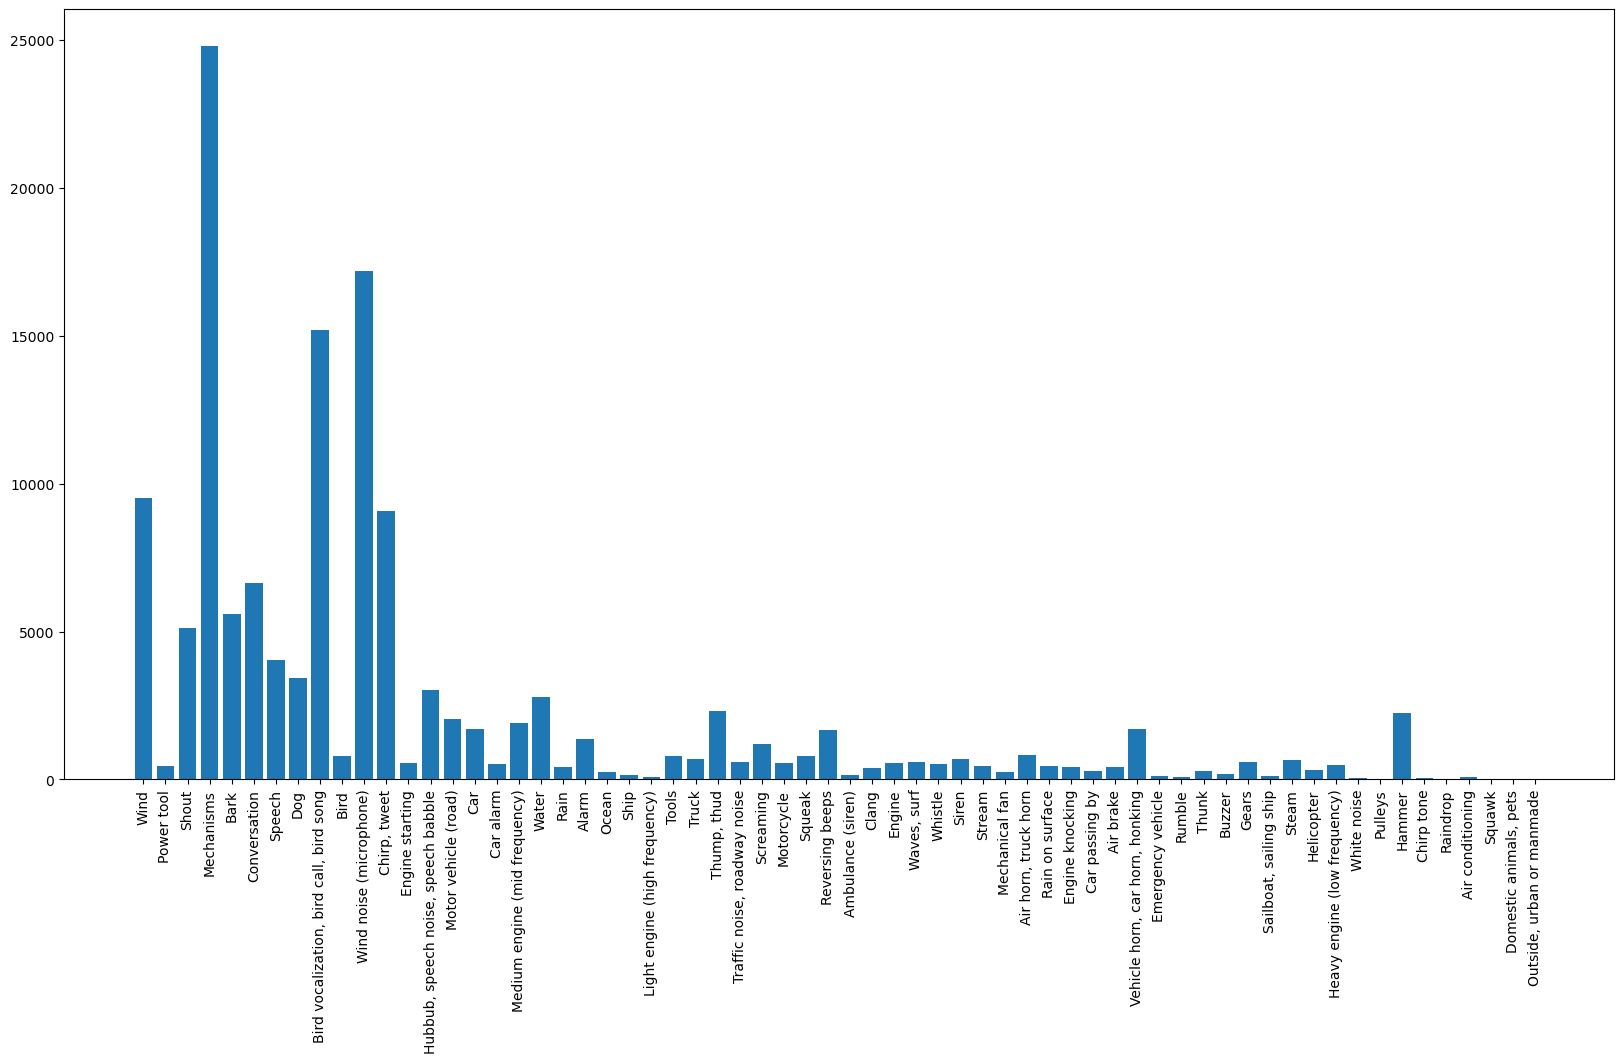

In [11]:
# plot the label count
plt.figure(figsize=(20,10))
plt.bar(label_count.keys(), label_count.values())
plt.xticks(rotation=90)
plt.show()

In [18]:
# plot the label with the fold count
fold_count = {}
for index, row in pd_train.iterrows():
    fold = row['fold']
    if fold in fold_count:
        fold_count[fold] += 1
    else:
        fold_count[fold] = 1
    
print(f"\nThis is the count for folds:\n {fold_count}")


This is the count for folds:
 {1: 110545, 2: 13795, 3: 13872}


In [22]:
# plot the fold count distribution per label
fold_label_count = {}
for index, row in pd_train.iterrows():
    label = row['display_name']
    fold = row['fold']
    if label in fold_label_count:
        if fold in fold_label_count[label]:
            fold_label_count[label][fold] += 1
        else:
            fold_label_count[label][fold] = 1
    else:
        fold_label_count[label] = {}
        fold_label_count[label][fold] = 1

print(f"\nThis is the count for folds per label:\n {fold_label_count}")


This is the count for folds per label:
 {'Wind': {1: 7605, 2: 950, 3: 952}, 'Power tool': {1: 362, 2: 45, 3: 46}, 'Shout': {1: 4096, 2: 512, 3: 512}, 'Mechanisms': {1: 19838, 2: 2479, 3: 2481}, 'Bark': {1: 4481, 2: 560, 3: 561}, 'Conversation': {1: 5316, 2: 664, 3: 665}, 'Speech': {1: 3232, 2: 404, 3: 404}, 'Dog': {1: 2744, 2: 343, 3: 344}, 'Bird vocalization, bird call, bird song': {1: 12146, 2: 1518, 3: 1519}, 'Bird': {1: 638, 2: 79, 3: 81}, 'Wind noise (microphone)': {1: 13752, 2: 1719, 3: 1719}, 'Chirp, tweet': {1: 7265, 2: 908, 3: 909}, 'Engine starting': {1: 434, 2: 54, 3: 55}, 'Hubbub, speech noise, speech babble': {1: 2432, 2: 304, 3: 304}, 'Motor vehicle (road)': {1: 1620, 2: 202, 3: 204}, 'Car': {1: 1374, 2: 171, 3: 173}, 'Car alarm': {1: 420, 2: 52, 3: 53}, 'Medium engine (mid frequency)': {1: 1512, 2: 189, 3: 190}, 'Water': {1: 2231, 2: 278, 3: 280}, 'Rain': {1: 325, 2: 40, 3: 42}, 'Alarm': {1: 1091, 2: 136, 3: 137}, 'Ocean': {1: 197, 2: 24, 3: 26}, 'Ship': {1: 121, 2: 15,

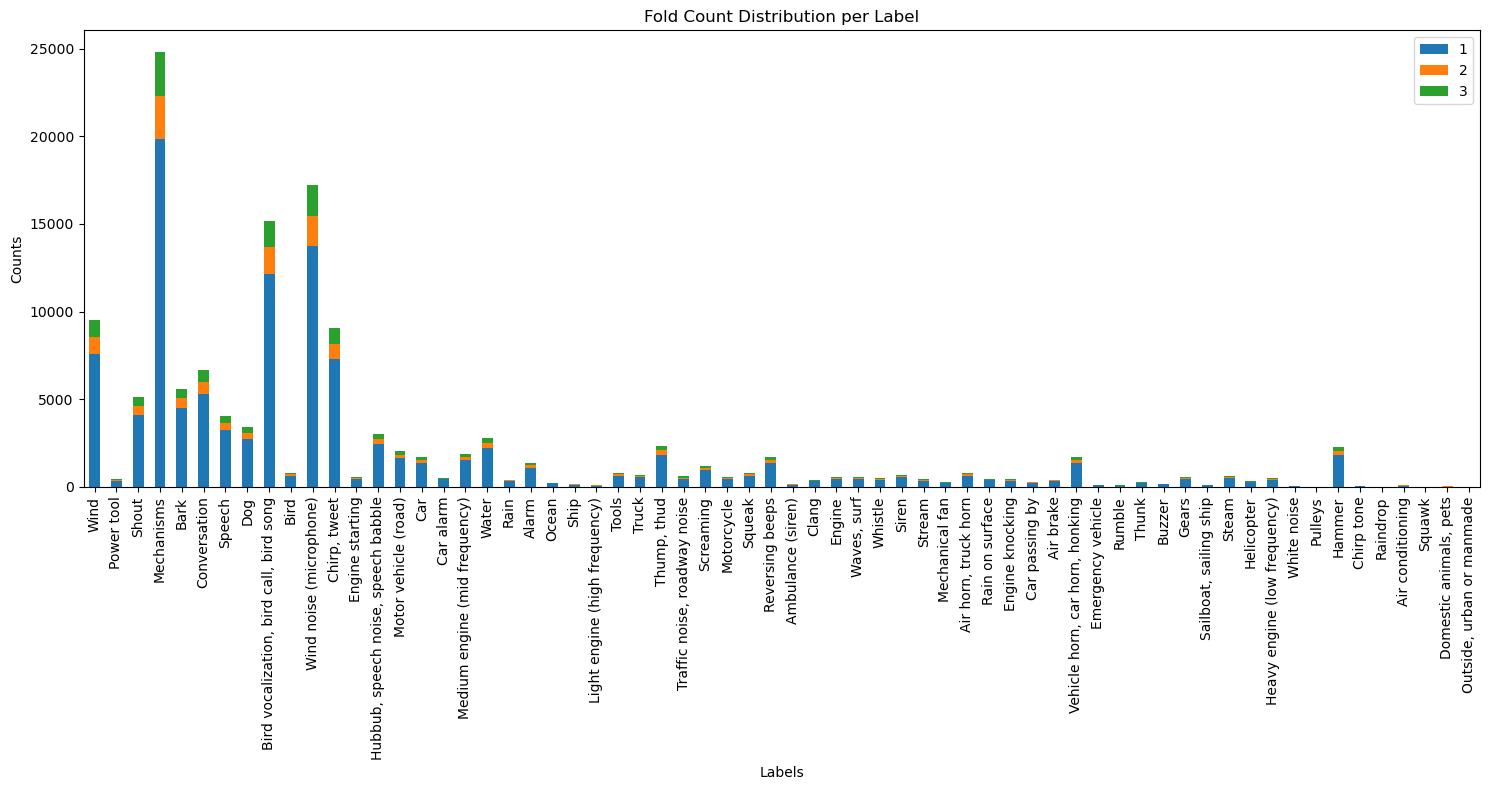

In [27]:
df = pd.DataFrame.from_dict(fold_label_count, orient='index').fillna(0).astype(int)

df.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Fold Count Distribution per Label')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.xticks(rotation=90)  

plt.tight_layout()
plt.show()

In [12]:
class_counts = pd_train['display_name'].value_counts().reset_index()
class_counts.columns = ['display_name', 'count']

fig = px.treemap(class_counts, 
                 path=['display_name'], 
                 values='count',
                 title='Distribution of Audio Classes in the TRAIN Dataset')

fig.show()

In [13]:
unique_classes = pd_train['display_name'].unique()

equal_value_df = pd.DataFrame({'display_name': unique_classes, 'value': 1})

fig = px.treemap(equal_value_df, 
                 path=['display_name'], 
                 values='value',
                 title='Equal Proportion Treemap of Audio Classes in the TRAIN Dataset')

fig.show()

In [14]:
print(f"These are the in the train dataset: \n\n{pd_train['display_name'].unique()}")

print(f"\nThere are {len(pd_train['display_name'].unique())} classes in the train dataset")

These are the in the train dataset: 

['Wind' 'Power tool' 'Shout' 'Mechanisms' 'Bark' 'Conversation' 'Speech'
 'Dog' 'Bird vocalization, bird call, bird song' 'Bird'
 'Wind noise (microphone)' 'Chirp, tweet' 'Engine starting'
 'Hubbub, speech noise, speech babble' 'Motor vehicle (road)' 'Car'
 'Car alarm' 'Medium engine (mid frequency)' 'Water' 'Rain' 'Alarm'
 'Ocean' 'Ship' 'Light engine (high frequency)' 'Tools' 'Truck'
 'Thump, thud' 'Traffic noise, roadway noise' 'Screaming' 'Motorcycle'
 'Squeak' 'Reversing beeps' 'Ambulance (siren)' 'Clang' 'Engine'
 'Waves, surf' 'Whistle' 'Siren' 'Stream' 'Mechanical fan'
 'Air horn, truck horn' 'Rain on surface' 'Engine knocking'
 'Car passing by' 'Air brake' 'Vehicle horn, car horn, honking'
 'Emergency vehicle' 'Rumble' 'Thunk' 'Buzzer' 'Gears'
 'Sailboat, sailing ship' 'Steam' 'Helicopter'
 'Heavy engine (low frequency)' 'White noise' 'Pulleys' 'Hammer'
 'Chirp tone' 'Raindrop' 'Air conditioning' 'Squawk'
 'Domestic animals, pets' 'Outside

In [15]:
port_66_classes = ['Wind', 'Shout', 'Mechanisms', 'Bark', 'Conversation', 'Speech',
                 'Dog', 'Bird vocalization, bird call, bird song', 'Bird',
                 'Wind noise (microphone)', 'Chirp, tweet', 'Engine starting',
                 'Hubbub, speech noise, speech babble', 'Motor vehicle (road)', 'Car',
                 'Car alarm', 'Medium engine (mid frequency)', 'Water', 'Rain', 'Alarm',
                 'Ocean', 'Ship', 'Light engine (high frequency)', 'Tools', 'Truck',
                 'Thump, thud', 'Traffic noise, roadway noise', 'Screaming', 'Motorcycle',
                 'Squeak', 'Reversing beeps', 'Ambulance (siren)', 'Clang', 'Engine',
                 'Waves, surf', 'Whistle', 'Siren', 'Stream', 'Mechanical fan',
                 'Air horn, truck horn', 'Rain on surface', 'Engine knocking',
                 'Car passing by', 'Air brake', 'Vehicle horn, car horn, honking',
                 'Emergency vehicle', 'Rumble', 'Thunk', 'Buzzer', 'Gears',
                 'Sailboat, sailing ship', 'Steam', 'Helicopter',
                 'Heavy engine (low frequency)', 'White noise', 'Pulleys', 'Hammer',
                 'Chirp tone', 'Raindrop', 'Air conditioning', 'Squawk',
                 'Domestic animals, pets', 'Outside, urban or manmade']

port_66_classes_to_id = {'Wind':0, 'Shout':1, 'Mechanisms':2, 'Bark':3, 'Conversation':4, 'Speech':5,
                 'Dog':6, 'Bird vocalization, bird call, bird song':7, 'Bird':8,
                 'Wind noise (microphone)':9, 'Chirp, tweet':10, 'Engine starting':11,
                 'Hubbub, speech noise, speech babble':12, 'Motor vehicle (road)':13, 'Car':14,
                 'Car alarm':15, 'Medium engine (mid frequency)':16, 'Water':17, 'Rain':18, 'Alarm':19,
                 'Ocean':20, 'Ship':21, 'Light engine (high frequency)':22, 'Tools':23, 'Truck':24,
                 'Thump, thud':25, 'Traffic noise, roadway noise':26, 'Screaming':27, 'Motorcycle':28,
                 'Squeak':29, 'Reversing beeps':30, 'Ambulance (siren)':31, 'Clang':32, 'Engine':33,
                 'Waves, surf':34, 'Whistle':35, 'Siren':36, 'Stream':37, 'Mechanical fan':38,
                 'Air horn, truck horn':39, 'Rain on surface':40, 'Engine knocking':41,
                 'Car passing by':42, 'Air brake':43, 'Vehicle horn, car horn, honking':44,
                 'Emergency vehicle':45, 'Rumble':46, 'Thunk':47, 'Buzzer':48, 'Gears':49,
                 'Sailboat, sailing ship':50, 'Steam':51, 'Helicopter':52,
                 'Heavy engine (low frequency)':53, 'White noise':54, 'Pulleys':55, 'Hammer':56,
                 'Chirp tone':57, 'Raindrop':58, 'Air conditioning':59, 'Squawk':60,
                 'Domestic animals, pets':61, 'Outside, urban or manmade':62}

In [30]:
filtered_pd = pd_train[pd_train.display_name.isin(port_66_classes)]

class_id = filtered_pd['display_name'].apply(lambda name: port_66_classes_to_id[name])
filtered_pd = filtered_pd.assign(target=class_id)

full_path = filtered_pd['filename'].apply(lambda name: os.path.join(base_data_path, base_train_path, name))
filtered_pd = filtered_pd.assign(filename=full_path)

# rename the column display_name to category
filtered_pd.rename(columns={'display_name': 'category'}, inplace=True)

# move column order: filename	fold	target	category
filtered_pd = filtered_pd[['filename', 'fold', 'target', 'category', 'segment_id', 'start_time_seconds', 'end_time_seconds', 'duration']]

filtered_pd.head(10)

,filename,fold,target,category,segment_id,start_time_seconds,end_time_seconds,duration
0,D:\AUDIOSET_STRONG\train_16k\0x7b99cd732dabfef...,1,0,Wind,b0RFKhbpFJA_30000,0.000,10.000,10.000
1,D:\AUDIOSET_STRONG\train_16k\-0x6da6a8a6c54e3a...,1,0,Wind,ZvAdd4Jb1xA_30000,0.000,10.000,10.000
2,D:\AUDIOSET_STRONG\train_16k\-0x52b316ded52fb6...,1,0,Wind,sWdJR9dInhw_19000,0.000,9.803,9.803
3,D:\AUDIOSET_STRONG\train_16k\0x4ea20c5a7d1cf99...,1,0,Wind,3zOfKHtXxws_30000,0.000,10.000,10.000
4,D:\AUDIOSET_STRONG\train_16k\0x5a0670380b88cad...,1,0,Wind,0r4zxu38gt0_0,0.083,10.000,9.917
5,D:\AUDIOSET_STRONG\train_16k\-0x1b9ae0c48b3ac1...,1,0,Wind,gICZlgNZuzo_370000,0.000,10.000,10.000
6,D:\AUDIOSET_STRONG\train_16k\-0x2634df9a06ed3f...,1,0,Wind,tstg4ljERAY_60000,0.000,10.000,10.000
7,D:\AUDIOSET_STRONG\train_16k\0x289574d47fdd8bb...,1,0,Wind,YdFfhvxPe2g_70000,0.000,9.465,9.465
8,D:\AUDIOSET_STRONG\train_16k\0x5eb0be1f2cf2551...,1,0,Wind,4XaFQxTLkfI_30000,0.008,10.000,9.992
9,D:\AUDIOSET_STRONG\train_16k\-0xa064f0b3d377ca...,1,0,Wind,CwQKT8z0OsI_30000,0.000,10.000,10.000


In [31]:
for index, row in filtered_pd.iterrows():
    # check if the file exists
    if not os.path.isfile(row['filename']):
        print("file not found: ", row['filename'])
        filtered_pd.drop(index, inplace=True)

In [32]:
filtered_pd.tail(10)

,filename,fold,target,category,segment_id,start_time_seconds,end_time_seconds,duration
141254,D:\AUDIOSET_STRONG\train_16k\0x189c1019996edbe...,1,61,"Domestic animals, pets",4S2R5UfWNBc_4000,8.466,8.708,0.242
141255,D:\AUDIOSET_STRONG\train_16k\-0x3a1a4bf836f580...,1,61,"Domestic animals, pets",FAmEQ-tIPQg_0,4.669,5.126,0.457
141256,D:\AUDIOSET_STRONG\train_16k\-0x36b6e899a12734...,1,61,"Domestic animals, pets",HovbbXiYNjw_0,0.589,1.611,1.022
141257,D:\AUDIOSET_STRONG\train_16k\-0x66efd7cfa407a7...,1,61,"Domestic animals, pets",RiUD33CPBfU_0,0.064,10.000,9.936
141258,D:\AUDIOSET_STRONG\train_16k\0x7511b41769e32c8...,2,61,"Domestic animals, pets",4lBcgIkI1Nk_28000,7.219,8.221,1.002
141259,D:\AUDIOSET_STRONG\train_16k\0x64108f4c27c01c8...,2,61,"Domestic animals, pets",pomUWYaREso_20000,0.906,1.984,1.078
141260,D:\AUDIOSET_STRONG\train_16k\0x46642ec89d316ae...,3,61,"Domestic animals, pets",pomUWYaREso_20000,3.134,4.094,0.960
141261,D:\AUDIOSET_STRONG\train_16k\0x1d60034a9896521...,3,61,"Domestic animals, pets",pomUWYaREso_20000,7.898,8.339,0.441
141262,D:\AUDIOSET_STRONG\train_16k\-0x6692ad1da5309a...,3,61,"Domestic animals, pets",pomUWYaREso_20000,9.173,9.740,0.567
141263,D:\AUDIOSET_STRONG\train_16k\-0x5c58b44adf0568...,3,62,"Outside, urban or manmade",sUVUOiVRLDY_40000,0.000,10.000,10.000


In [33]:
filenames = filtered_pd['filename']
targets = filtered_pd['target']
folds = filtered_pd['fold']

main_ds = tf.data.Dataset.from_tensor_slices(
    (filtered_pd['filename'], filtered_pd['target'], filtered_pd['fold'], 
     filtered_pd['start_time_seconds'], filtered_pd['end_time_seconds'])
)
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.float64, name=None),
 TensorSpec(shape=(), dtype=tf.float64, name=None))

In [37]:
def load_wav_for_map(filename, label, fold, start_time, end_time):
    start_time = tf.cast(start_time, tf.float32)
    end_time = tf.cast(end_time, tf.float32)
    return load_wav_16k_mono(filename, start_time, end_time), label, fold

main_ds = main_ds.map(load_wav_for_map)

main_ds.element_spec

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [39]:
# applies the embedding extraction model to a wav data
def extract_embedding(wav_data, label, fold):
  ''' run YAMNet to extract embedding from the wav data '''
  scores, embeddings, spectrogram = yamnet(audio_file)
  num_embeddings = tf.shape(embeddings)[0]
  
  return (embeddings,
            tf.repeat(label, num_embeddings),
            tf.repeat(fold, num_embeddings))

# extract embedding
main_ds = main_ds.map(extract_embedding).unbatch()
main_ds.element_spec

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


(TensorSpec(shape=(1024,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [40]:
# split the dataset into train, eval and test
cached_ds = main_ds.cache()
train_ds = cached_ds.filter(lambda embedding, label, fold: fold < 3)
val_ds = cached_ds.filter(lambda embedding, label, fold: fold == 2)
test_ds = cached_ds.filter(lambda embedding, label, fold: fold == 3)

# remove the fold column
remove_fold = lambda embedding, label, fold: (embedding, label)

train_ds = train_ds.map(remove_fold)
val_ds = val_ds.map(remove_fold)
test_ds = test_ds.map(remove_fold)

# shuffle the train dataset
# train_ds = train_ds.shuffle(100, reshuffle_each_iteration=True) # reshuffle_each_iteration=True
train_ds = train_ds.cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

In [41]:
# create the model
port_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024), dtype=tf.float32, name='input_embedding'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(len(port_66_classes), activation='softmax')
], name='audioset_port_classifier')

port_model.summary()

Model: "audioset_port_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 512)               524800    
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dense_3 (Dense)             (None, 63)                16191     
                                                                 


Total params: 672,319
Trainable params: 672,319
Non-trainable params: 0
_________________________________________________________________


In [42]:
port_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 optimizer="adam",
                 metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3,
                                            restore_best_weights=True)

In [43]:
history = port_model.fit(train_ds,
                       epochs=20,
                       validation_data=val_ds,
                       callbacks=callback)

Epoch 1/20
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


c:\Users\GIS2\.conda\envs\inference\lib\site-packages\keras\backend.py:5586: UserWarning:

"`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?



    176/Unknown - 30s 128ms/step - loss: 0.0517 - accuracy: 0.9943

KeyboardInterrupt: 

### Evaluate

Let's run the `evaluate` method on the test data just to be sure there's no overfitting.

In [ ]:
loss, accuracy = port_model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

5/5 [==============================] - 0s 2ms/step - loss: 0.5052 - accuracy: 0.8125
Loss:  0.5051699876785278
Accuracy:  0.8125


## Test your model

Next, try your model on the embedding from the previous test using YAMNet only.


In [ ]:
scores, embeddings, spectrogram = yamnet_model(testing_wav_data)
result = my_model(embeddings).numpy()

inferred_class = my_classes[result.mean(axis=0).argmax()]
print(f'The main sound is: {inferred_class}')

The main sound is: cat


## Save a model that can directly take a WAV file as input

Your model works when you give it the embeddings as input.

In a real-world scenario, you'll want to use audio data as a direct input.

To do that, you will combine YAMNet with your model into a single model that you can export for other applications.

To make it easier to use the model's result, the final layer will be a `reduce_mean` operation. When using this model for serving (which you will learn about later in the tutorial), you will need the name of the final layer. If you don't define one, TensorFlow will auto-define an incremental one that makes it hard to test, as it will keep changing every time you train the model. When using a raw TensorFlow operation, you can't assign a name to it. To address this issue, you'll create a custom layer that applies `reduce_mean` and call it `'classifier'`.


In [ ]:
class ReduceMeanLayer(tf.keras.layers.Layer):
  def __init__(self, axis=0, **kwargs):
    super(ReduceMeanLayer, self).__init__(**kwargs)
    self.axis = axis

  def call(self, input):
    return tf.math.reduce_mean(input, axis=self.axis)

In [ ]:
saved_model_path = './dogs_and_cats_yamnet'

input_segment = tf.keras.layers.Input(shape=(), dtype=tf.float32, name='audio')
embedding_extraction_layer = hub.KerasLayer(yamnet_model_handle,
                                            trainable=False, name='yamnet')
_, embeddings_output, _ = embedding_extraction_layer(input_segment)
serving_outputs = my_model(embeddings_output)
serving_outputs = ReduceMeanLayer(axis=0, name='classifier')(serving_outputs)
serving_model = tf.keras.Model(input_segment, serving_outputs)
serving_model.save(saved_model_path, include_optimizer=False)

INFO:tensorflow:Assets written to: ./dogs_and_cats_yamnet/assets


INFO:tensorflow:Assets written to: ./dogs_and_cats_yamnet/assets


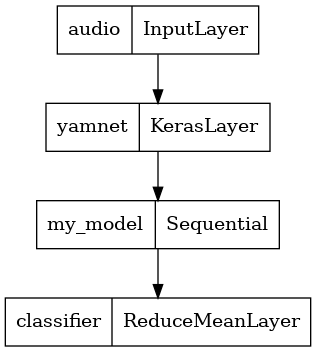

In [ ]:
tf.keras.utils.plot_model(serving_model)

Load your saved model to verify that it works as expected.

In [ ]:
reloaded_model = tf.saved_model.load(saved_model_path)

And for the final test: given some sound data, does your model return the correct result?

In [ ]:
reloaded_results = reloaded_model(testing_wav_data)
cat_or_dog = my_classes[tf.math.argmax(reloaded_results)]
print(f'The main sound is: {cat_or_dog}')

The main sound is: cat


If you want to try your new model on a serving setup, you can use the 'serving_default' signature.

In [ ]:
serving_results = reloaded_model.signatures['serving_default'](testing_wav_data)
cat_or_dog = my_classes[tf.math.argmax(serving_results['classifier'])]
print(f'The main sound is: {cat_or_dog}')


The main sound is: cat


## (Optional) Some more testing

The model is ready.

Let's compare it to YAMNet on the test dataset.

./datasets/ESC-50-master/audio/5-172299-A-5.wav


Waveform values: [-1.0854422e-06  3.1059460e-06 -1.3652678e-06 ...  1.6882542e-01
  1.3804492e-01  5.8870625e-02]


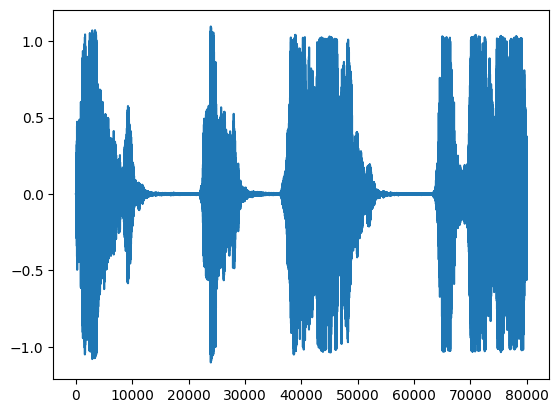

In [ ]:
test_pd = filtered_pd.loc[filtered_pd['fold'] == 5]
row = test_pd.sample(1)
filename = row['filename'].item()
print(filename)
waveform = load_wav_16k_mono(filename)
print(f'Waveform values: {waveform}')
_ = plt.plot(waveform)

display.Audio(waveform, rate=16000)

In [ ]:
# Run the model, check the output.
scores, embeddings, spectrogram = yamnet_model(waveform)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.math.argmax(class_scores)
inferred_class = class_names[top_class]
top_score = class_scores[top_class]
print(f'[YAMNet] The main sound is: {inferred_class} ({top_score})')

reloaded_results = reloaded_model(waveform)
your_top_class = tf.math.argmax(reloaded_results)
your_inferred_class = my_classes[your_top_class]
class_probabilities = tf.nn.softmax(reloaded_results, axis=-1)
your_top_score = class_probabilities[your_top_class]
print(f'[Your model] The main sound is: {your_inferred_class} ({your_top_score})')

[YAMNet] The main sound is: Domestic animals, pets (0.5051151514053345)
[Your model] The main sound is: cat (0.996594250202179)


## Next steps

You have created a model that can classify sounds from dogs or cats. With the same idea and a different dataset you can try, for example, building an [acoustic identifier of birds](https://www.kaggle.com/c/birdclef-2021/) based on their singing.

Share your project with the TensorFlow team on social media!
